# Seminar Assignment: Exercise 2 - Representing Provenance
**Goal**: To document the provenance of a student financial support survey using the W3C PROV standard.

**Scenario**: 
- Laura designs an initial survey.
- Jack and Jill collect the first set of data.
- Laura revises the survey.
- Peter and Paula collect the second set of data.
- Zack compiles and analyzes all results to publish a paper with Laura.

In [1]:
!pip install prov pydot
from prov.model import ProvDocument
from datetime import datetime


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Create a new PROV document
d1 = ProvDocument()

# Define Namespaces
d1.add_namespace('ex', 'http://example.org/')

# 1. Define Agents (The Who)
laura = d1.agent('Laura', {'prov:type': 'prov:Person'})
jack = d1.agent('Jack', {'prov:type': 'prov:Person'})
jill = d1.agent('Jill', {'prov:type': 'prov:Person'})
peter = d1.agent('Peter', {'prov:type': 'prov:Person'})
paula = d1.agent('Paula', {'prov:type': 'prov:Person'})
zack = d1.agent('Zack', {'prov:type': 'prov:Person'})

# 2. Define Activities (The How)
act_design1 = d1.activity('DesignSurvey_v1', datetime.now())
act_conduct1 = d1.activity('ConductSurvey_1', datetime.now())
act_revise = d1.activity('ReviseSurvey', datetime.now())
act_conduct2 = d1.activity('ConductSurvey_2', datetime.now())
act_analyze = d1.activity('AnalyzeResults', datetime.now())

# 3. Define Entities (The What)
survey_v1 = d1.entity('SurveyDesign_v1', {'prov:label': 'Initial Survey Plan'})
data_1 = d1.entity('SurveyData_1')
survey_v2 = d1.entity('SurveyDesign_v2', {'prov:label': 'Revised Survey Plan'})
data_2 = d1.entity('SurveyData_2')
compiled_data = d1.entity('CompiledResults')
paper = d1.entity('FinalPaper')

# 4. Define Relationships (Connections) 
# Phase 1
d1.wasGeneratedBy(survey_v1, act_design1)
d1.wasAssociatedWith(act_design1, laura)

d1.used(act_conduct1, survey_v1) # Survey v1 acts as a "Plan"
d1.wasGeneratedBy(data_1, act_conduct1)
d1.wasAssociatedWith(act_conduct1, jack)
d1.wasAssociatedWith(act_conduct1, jill)

# Phase 2 (Revision)
d1.used(act_revise, survey_v1)
d1.wasGeneratedBy(survey_v2, act_revise)
d1.wasRevisionOf(survey_v2, survey_v1)
d1.wasAssociatedWith(act_revise, laura)

d1.used(act_conduct2, survey_v2) # Survey v2 acts as a "Plan"
d1.wasGeneratedBy(data_2, act_conduct2)
d1.wasAssociatedWith(act_conduct2, peter)
d1.wasAssociatedWith(act_conduct2, paula)

# Analysis & Publication
d1.used(act_analyze, data_1)
d1.used(act_analyze, data_2)
d1.wasGeneratedBy(compiled_data, act_analyze)
d1.wasAssociatedWith(act_analyze, zack)

d1.wasDerivedFrom(paper, compiled_data)
d1.wasAttributedTo(paper, zack)
d1.wasAttributedTo(paper, laura)

print("PROV document created successfully.")

PROV document created successfully.


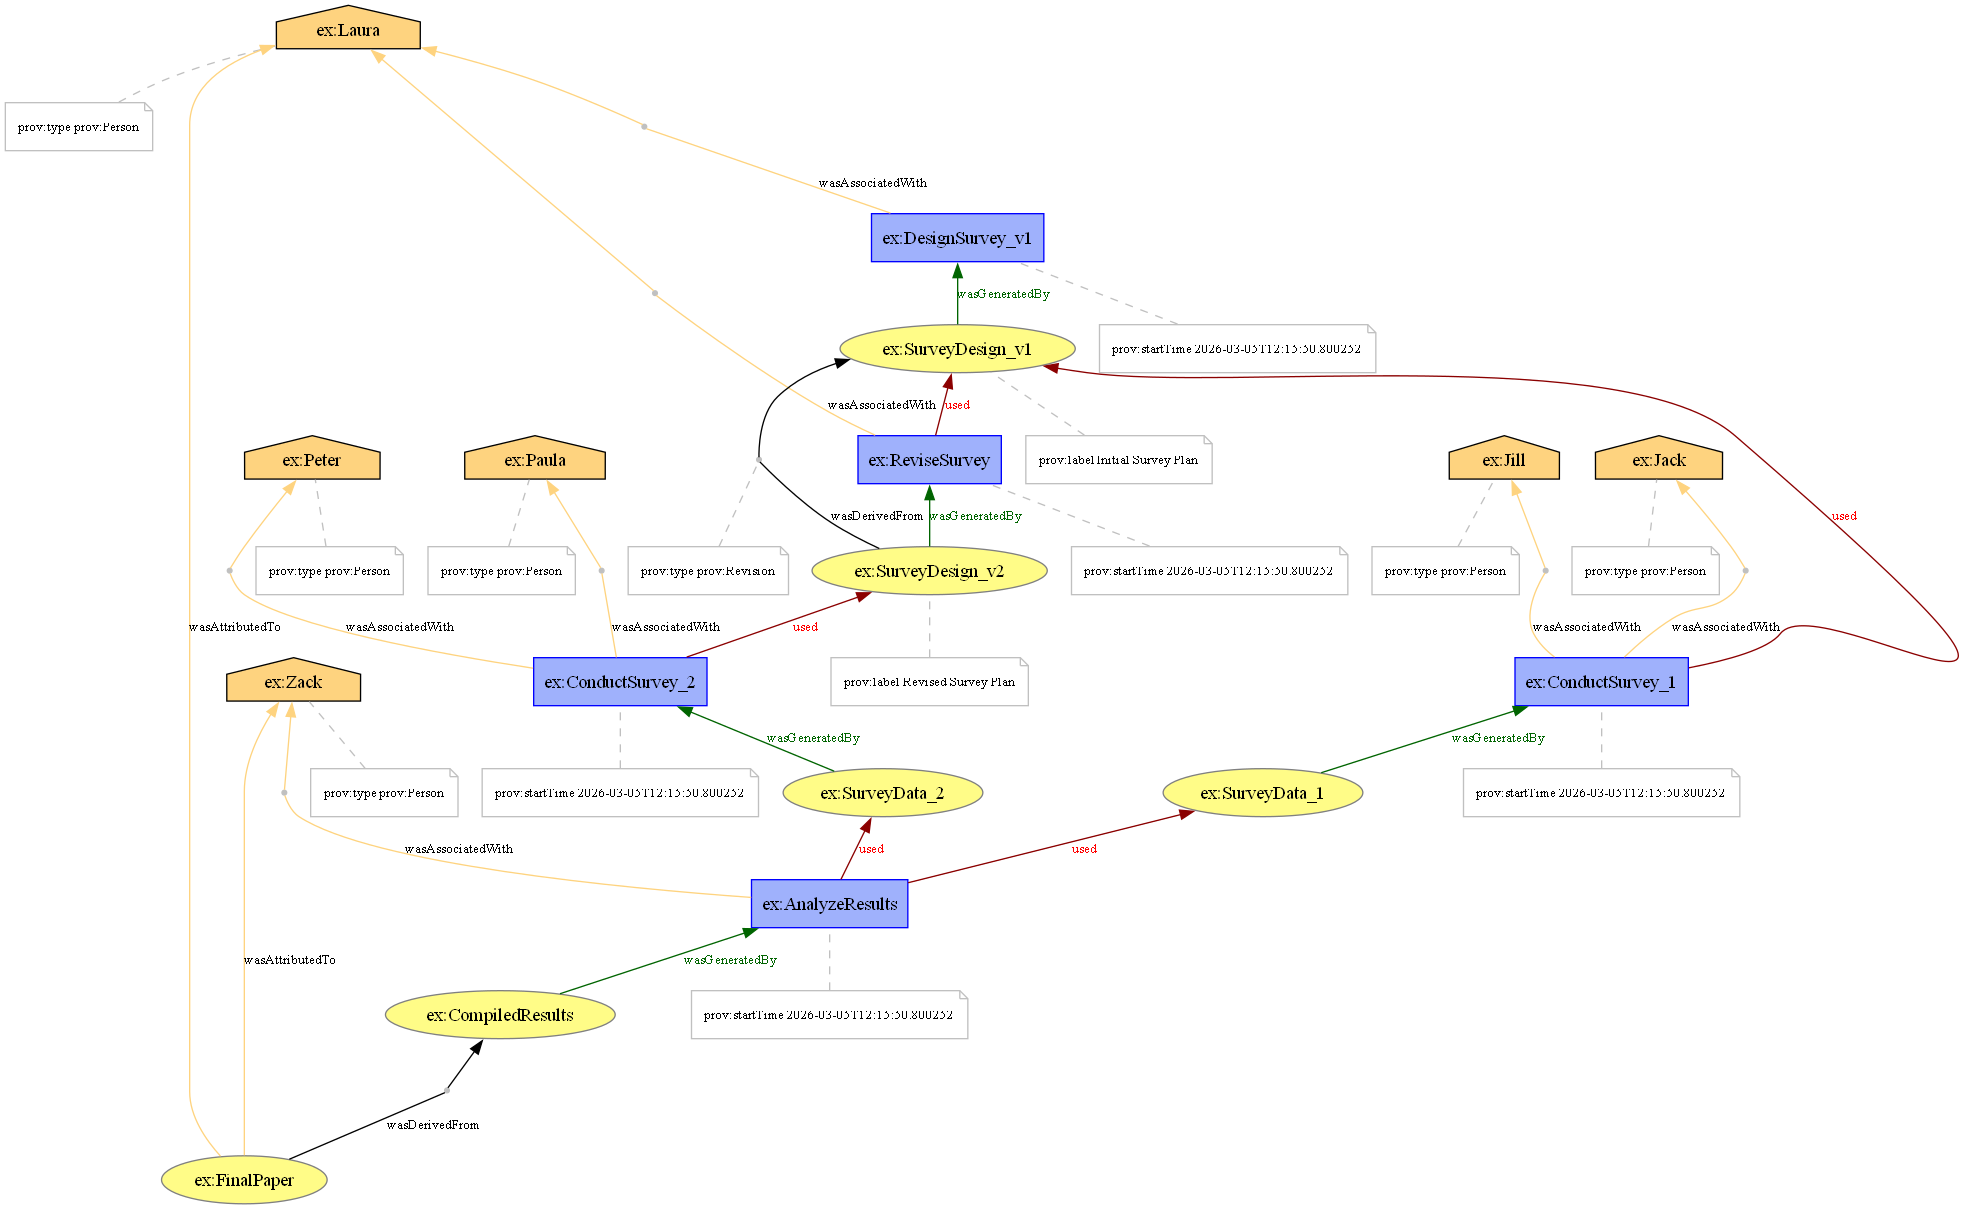

Success! The diagram 'provenance_diagram.png' has been created.


In [7]:
import os
from prov.dot import prov_to_dot
from IPython.display import Image

# 1. Fixed the typo to 'os.pathsep'
# 2. Used 'r' before the string to handle the backslashes correctly
graphviz_path = r'D:\Noua_ierarhie\Installs\Normal\Graphviz-14.1.2-win64\bin'

if graphviz_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + graphviz_path

try:
    # Ensure you have run the previous cell where d1 (the ProvDocument) is defined!
    dot = prov_to_dot(d1)
    
    # Save as a PNG
    dot.write_png('provenance_diagram.png')
    
    # Display it in the notebook
    display(Image('provenance_diagram.png'))
    print("Success! The diagram 'provenance_diagram.png' has been created.")
except Exception as e:
    print(f"Error generating diagram: {e}")
    print("\nTroubleshooting:")
    print("1. Make sure you run the cell that creates 'd1' before this one.")
    print("2. Verify that 'dot.exe' exists in the folder: " + graphviz_path)